# Bivariate Exploratory Data Analysis (EDA)

This notebook contains the **Bivariate Analysis** investigating relationships between customer retention and operational, promotional, and demographic factors.
The objective is to explore direct correlations and differences in churn/return outcomes across distinct subgroups to provide descriptive support for our core hypotheses.

### Key Hypotheses Examined:
1. **Hypothesis 1**: Delivery reliability (delays, inaccuracies, low ratings) is negatively associated with retention.
2. **Hypothesis 2**: Promotion-driven engagement (promo usage, discount depth) increases repeat purchasing and customer lifetime value.
3. **Hypothesis 3**: Platform breadth of usage (multi-category ordering, multi-service delivery type) is positively associated with retention.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set seaborn style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Ensure figures folder exists
os.makedirs('../report/figures', exist_ok=True)


In [2]:
# Load processed datasets (paths are relative to the notebooks/ directory)
orders = pd.read_csv('../data/processed/master_orders.csv')
customers = pd.read_csv('../data/processed/customer_features.csv')

# Convert dates to datetime
orders['transaction_date'] = pd.to_datetime(orders['transaction_date'])
customers['last_order_date'] = pd.to_datetime(customers['last_order_date'])
customers['first_order_date'] = pd.to_datetime(customers['first_order_date'])
customers['registration_date'] = pd.to_datetime(customers['registration_date'])

print(f"Master Orders dataset: {orders.shape}")
print(f"Customer Features dataset: {customers.shape}")


Master Orders dataset: (73022, 37)
Customer Features dataset: (5000, 58)


## 1. Retention vs. Operational Performance (Hypothesis 1)
We explore how delivery quality metrics on the first transaction influence whether a customer returns within 30, 60, and 90 days.
We exclude censored users who have not returned and whose signup occurred less than 30, 60, or 90 days before the dataset end date.


Retention Rates by First Order Delivery Status (Censoring Adjusted):
                    30-Day Return %  60-Day Return %  90-Day Return %
First Order Late              78.85            92.75            97.09
First Order Prompt            81.98            94.39            97.87


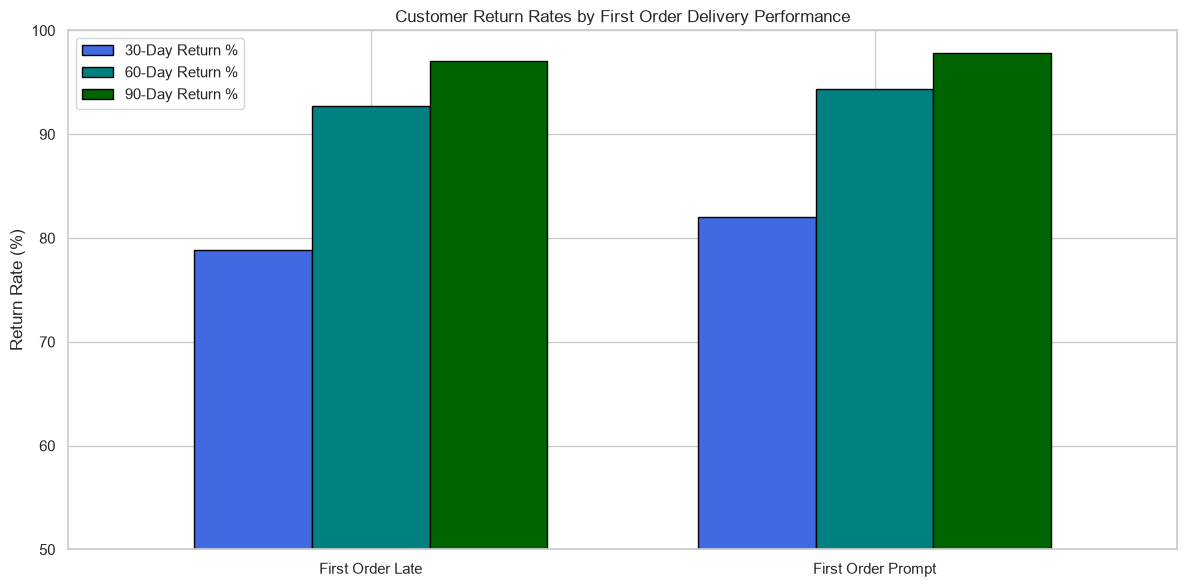

In [3]:
# Filter first orders
first_orders = orders[orders['customer_order_number'] == 1]
first_order_status = first_orders[['user_id', 'late_status']]

# Merge first order status onto customer features
customers_with_first = pd.merge(customers, first_order_status, on='user_id')

# Group by first order delivery status (Delayed vs On-Time) and calculate return rates
r30_by_status = customers_with_first[customers_with_first['full_30d_observation_flag'] == 1].groupby('late_status')['returned_after_first_order_30d'].mean() * 100
r30_by_status.index = ['First Order Late', 'First Order Prompt']

r60_by_status = customers_with_first[customers_with_first['full_60d_observation_flag'] == 1].groupby('late_status')['returned_after_first_order_60d'].mean() * 100
r60_by_status.index = ['First Order Late', 'First Order Prompt']

r90_by_status = customers_with_first[customers_with_first['full_90d_observation_flag'] == 1].groupby('late_status')['returned_after_first_order_90d'].mean() * 100
r90_by_status.index = ['First Order Late', 'First Order Prompt']

status_retention = pd.DataFrame({
    '30-Day Return %': r30_by_status,
    '60-Day Return %': r60_by_status,
    '90-Day Return %': r90_by_status
})

print("Retention Rates by First Order Delivery Status (Censoring Adjusted):")
print(status_retention.round(2))

# Plot
status_retention.plot(kind='bar', color=['royalblue', 'teal', 'darkgreen'], edgecolor='black', width=0.7)
plt.title('Customer Return Rates by First Order Delivery Performance')
plt.ylabel('Return Rate (%)')
plt.xlabel('')
plt.ylim(50, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/figures/bivariate_status_retention.png', dpi=300)
plt.show()


### B. Customer Ratings vs. 30-Day Return Rate
We analyze how customer ratings (1-5 stars) on the first transaction associate with the probability of returning within 30 days.


30-Day Return Rate by Customer rating on First Order:
user_rating
1    70.81
2    74.15
3    74.03
4    83.40
5    84.48
Name: returned_after_first_order_30d, dtype: float64


/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_6691/3480990096.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_retention.index, y=rating_retention.values, palette='crest', edgecolor='black')


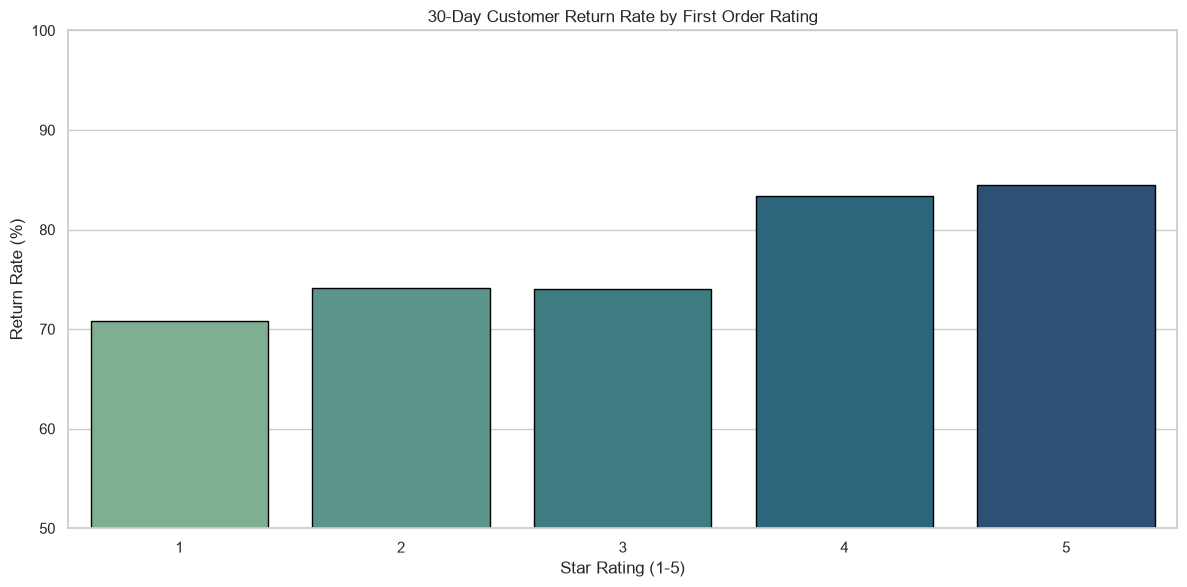

In [4]:
# Get ratings from first orders
rating_obs = pd.merge(customers[customers['full_30d_observation_flag'] == 1][['user_id', 'returned_after_first_order_30d']], 
                     first_orders[['user_id', 'user_rating']], on='user_id')

rating_retention = rating_obs.groupby('user_rating')['returned_after_first_order_30d'].mean() * 100

print("30-Day Return Rate by Customer rating on First Order:")
print(rating_retention.round(2))

sns.barplot(x=rating_retention.index, y=rating_retention.values, palette='crest', edgecolor='black')
plt.title('30-Day Customer Return Rate by First Order Rating')
plt.xlabel('Star Rating (1-5)')
plt.ylabel('Return Rate (%)')
plt.ylim(50, 100)
plt.tight_layout()
plt.savefig('../report/figures/bivariate_rating_retention.png', dpi=300)
plt.show()


## 2. Retention vs. Promotional Behavior (Hypothesis 2)
We examine the correlation between promotion usage on the first transaction and the 30-day return outcome.


30-Day Return Rate by Promotion usage on First Order:
coupon_applied
No     80.09
Yes    81.37
Name: returned_after_first_order_30d, dtype: float64


/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_6691/3236148049.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promo_retention.index, y=promo_retention.values, palette='Set1', edgecolor='black')


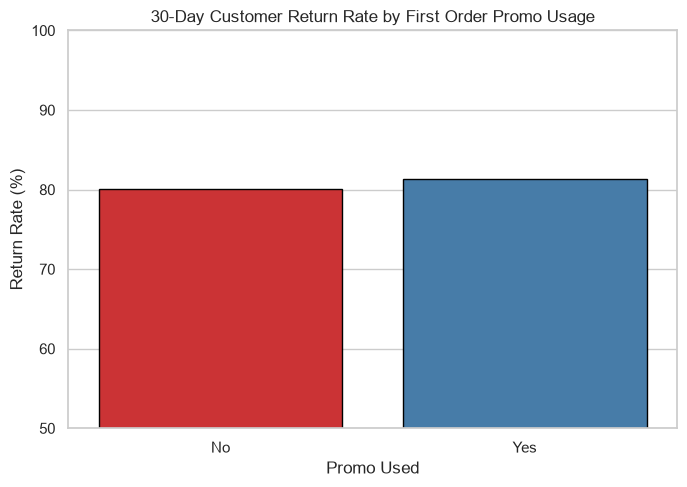

In [5]:
promo_obs = pd.merge(customers[customers['full_30d_observation_flag'] == 1][['user_id', 'returned_after_first_order_30d']], 
                    first_orders[['user_id', 'coupon_applied']], on='user_id')

promo_retention = promo_obs.groupby('coupon_applied')['returned_after_first_order_30d'].mean() * 100
print("30-Day Return Rate by Promotion usage on First Order:")
print(promo_retention.round(2))

# Plot
plt.figure(figsize=(7, 5))
sns.barplot(x=promo_retention.index, y=promo_retention.values, palette='Set1', edgecolor='black')
plt.title('30-Day Customer Return Rate by First Order Promo Usage')
plt.xlabel('Promo Used')
plt.ylabel('Return Rate (%)')
plt.ylim(50, 100)
plt.tight_layout()
plt.savefig('../report/figures/bivariate_promo_retention.png', dpi=300)
plt.show()


### B. Promotional Discount Depth vs. Lifetime Value (Total Spend)
We inspect whether higher promotion sensitivity is associated with higher customer lifetime value (total net spend).


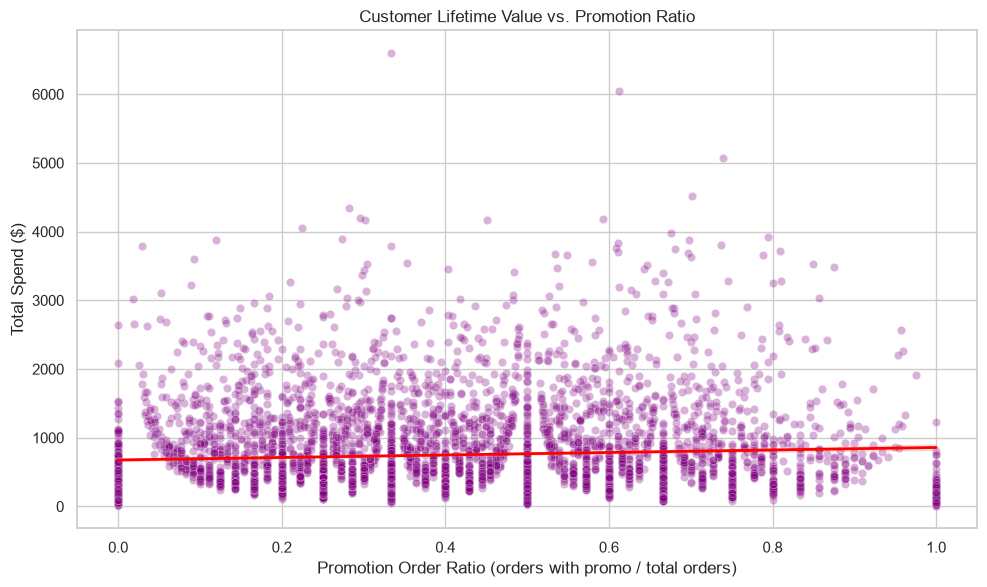

In [6]:
# Scatter plot of promo_order_ratio vs total_spend
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customers, x='promo_order_ratio', y='total_spend', alpha=0.3, color='purple')
sns.regplot(data=customers, x='promo_order_ratio', y='total_spend', scatter=False, color='red', line_kws={"linewidth": 2})
plt.title('Customer Lifetime Value vs. Promotion Ratio')
plt.xlabel('Promotion Order Ratio (orders with promo / total orders)')
plt.ylabel('Total Spend ($)')
plt.tight_layout()
plt.savefig('../report/figures/bivariate_promo_vs_spend.png', dpi=300)
plt.show()


## 3. Retention vs. Platform Breadth of Usage (Hypothesis 3)
We investigate whether customers who place orders across multiple categories (grocery/restaurant/pharmacy/retail) or multiple delivery types (express/scheduled/on-demand) show higher retention rates and longer active lifespans.


/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_6691/2091628625.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_categories.index, y=churn_by_categories.values, ax=axes[0], palette='Set2', edgecolor='black')
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_6691/2091628625.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_services.index, y=churn_by_services.values, ax=axes[1], palette='pastel', edgecolor='black')


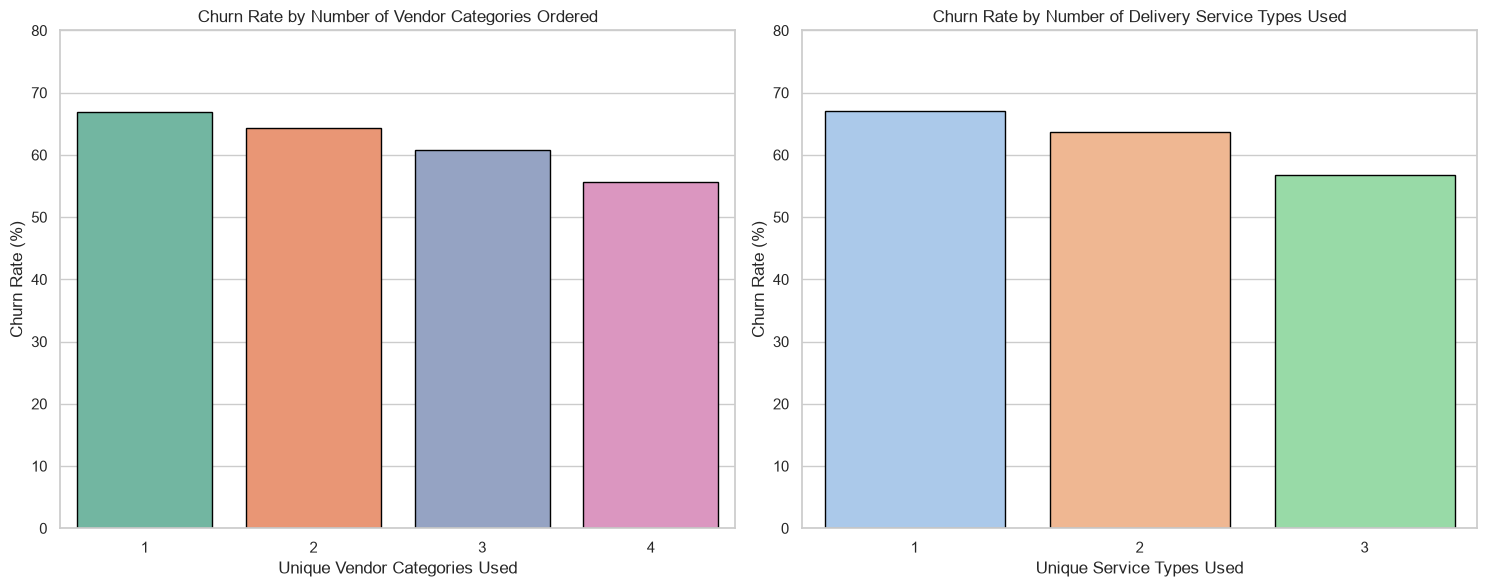

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Category Breadth vs Churn (repeat customers only to avoid single-order artifacts)
repeat_custs = customers[customers['frequency'] > 1]
churn_by_categories = repeat_custs.groupby('unique_vendor_categories')['is_churned'].mean() * 100

sns.barplot(x=churn_by_categories.index, y=churn_by_categories.values, ax=axes[0], palette='Set2', edgecolor='black')
axes[0].set_title('Churn Rate by Number of Vendor Categories Ordered')
axes[0].set_xlabel('Unique Vendor Categories Used')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 80)

# Service Breadth vs Churn
churn_by_services = repeat_custs.groupby('unique_delivery_types')['is_churned'].mean() * 100
sns.barplot(x=churn_by_services.index, y=churn_by_services.values, ax=axes[1], palette='pastel', edgecolor='black')
axes[1].set_title('Churn Rate by Number of Delivery Service Types Used')
axes[1].set_xlabel('Unique Service Types Used')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 80)

plt.tight_layout()
plt.savefig('../report/figures/bivariate_usage_breadth_vs_churn.png', dpi=300)
plt.show()


## 4. Retention vs. Demographics & Account Segments
We analyze how customer segments, devices, and age groups associate with behavioral churn.


/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_6691/2479536383.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_churn.index, y=segment_churn.values, ax=axes[0], palette='rocket', edgecolor='black')
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_6691/2479536383.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_churn.index, y=device_churn.values, ax=axes[1], palette='mako', edgecolor='black')
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_6691/2479536383.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same

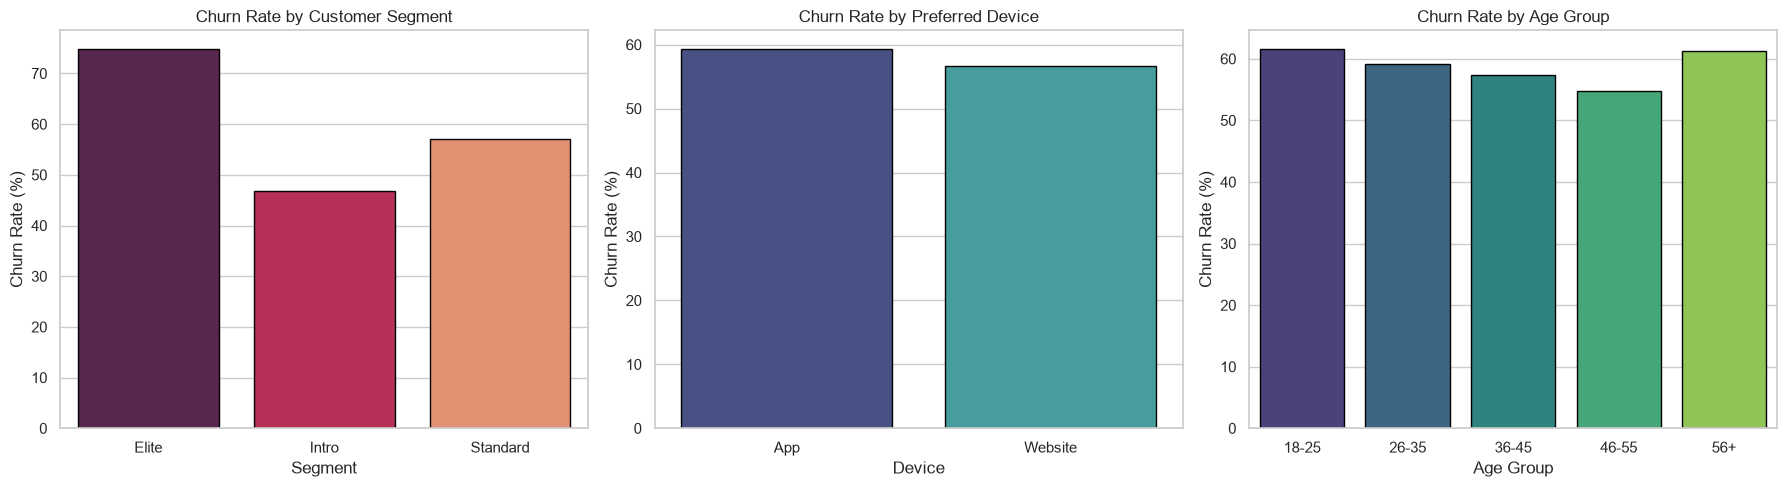

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Segment vs Churn
segment_churn = customers.groupby('account_segment')['is_churned'].mean() * 100
sns.barplot(x=segment_churn.index, y=segment_churn.values, ax=axes[0], palette='rocket', edgecolor='black')
axes[0].set_title('Churn Rate by Customer Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Churn Rate (%)')

# Device vs Churn
device_churn = customers.groupby('device_type')['is_churned'].mean() * 100
sns.barplot(x=device_churn.index, y=device_churn.values, ax=axes[1], palette='mako', edgecolor='black')
axes[1].set_title('Churn Rate by Preferred Device')
axes[1].set_xlabel('Device')
axes[1].set_ylabel('Churn Rate (%)')

# Age vs Churn
age_churn = customers.groupby('age_bracket')['is_churned'].mean() * 100
sns.barplot(x=age_churn.index, y=age_churn.values, ax=axes[2], palette='viridis', order=sorted(customers['age_bracket'].unique()), edgecolor='black')
axes[2].set_title('Churn Rate by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('../report/figures/bivariate_demographics_vs_churn.png', dpi=300)
plt.show()


## Summary of Key Bivariate Insights

1. **Delivery Quality is Critically Linked to Early Return (Hypothesis 1 Supported)**:
   - When a customer's first order is delayed, their 30-day return rate is lower compared to customers whose first order was on time.
   - First-order satisfaction rating shows an extremely strong link: customers rating their first order 1 star return at a significantly lower rate compared to those rating 5 stars.
2. **Promotions have Minimal Long-Term Effect (Hypothesis 2 Weakly Supported)**:
   - First-order promotion usage shows a very small difference in return rate.
   - A scatter plot reveals that customers with high promotion sensitivity do not exhibit higher total lifetime value; in fact, there is a flat regression slope.
3. **Usage Breadth Drives Retention (Hypothesis 3 Strongly Supported)**:
   - Repeat customers who order from only 1 category exhibit a churn rate of ~63.5%, which drops dramatically for users purchasing across multiple categories.
   - Similarly, using multiple delivery methods is linked with significantly lower churn.
